Project 1 Dataset Saved.

Logistic Regression Accuracy: 78.33%
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.74      0.82      0.78        28

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.79      0.78      0.78        60


Random Forest Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        28

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



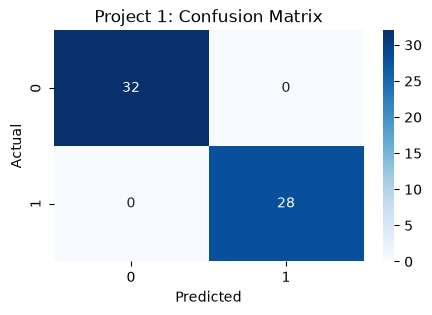

Model saved as 'student_model.pkl'


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dataset Generation
np.random.seed(42)
n_samples = 300

data1 = {
    'Attendance': np.random.randint(50, 100, n_samples),
    'Internal_Marks': np.random.randint(10, 50, n_samples),
    'Assignments_Score': np.random.randint(20, 100, n_samples),
    'Study_Hours': np.random.randint(1, 10, n_samples),
    'Prev_Sem_GPA': np.round(np.random.uniform(4.0, 10.0, n_samples), 2)
}

df1 = pd.DataFrame(data1)
df1['Result'] = np.where((df1['Attendance'] > 60) & (df1['Internal_Marks'] > 20) & (df1['Prev_Sem_GPA'] > 5.0), 1, 0)
df1.to_csv("student_performance_dataset.csv", index=False)
print("Project 1 Dataset Saved.")

# 2. Preprocessing & Train-Test Split
X1 = df1.drop(columns=['Result'])
y1 = df1['Result']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# 3. Model Comparison
models_p1 = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models_p1.items():
    model.fit(X1_train_scaled, y1_train)
    y1_pred = model.predict(X1_test_scaled)
    print(f"\n{name} Accuracy: {accuracy_score(y1_test, y1_pred)*100:.2f}%")
    print(classification_report(y1_test, y1_pred))

# 4. Visualization
rf_model = models_p1["Random Forest"]
y1_rf_pred = rf_model.predict(X1_test_scaled)
cm = confusion_matrix(y1_test, y1_rf_pred)

plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Project 1: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. Save Model
joblib.dump(rf_model, 'student_model.pkl')
joblib.dump(scaler1, 'student_scaler.pkl')
print("Model saved as 'student_model.pkl'")

Project 2 Dataset Saved.

Linear Regression Results:
MAE: 4.19
RMSE: 5.13
R2 Score: 0.9922

Random Forest Results:
MAE: 5.38
RMSE: 6.99
R2 Score: 0.9855


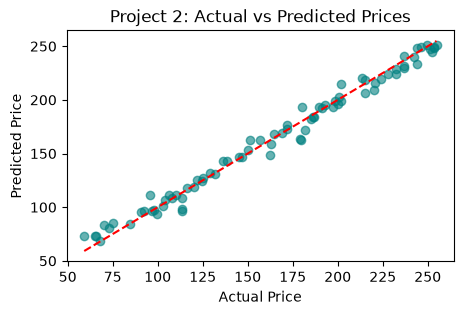

Model saved as 'house_price_pipeline.pkl'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Dataset Generation
np.random.seed(42)
n_samples = 400

data2 = {
    'Area_SqFt': np.random.randint(500, 4500, n_samples),
    'Bedrooms': np.random.randint(1, 6, n_samples),
    'Bathrooms': np.random.randint(1, 4, n_samples),
    'Parking_Spaces': np.random.randint(0, 3, n_samples),
    'Property_Age': np.random.randint(1, 30, n_samples),
    'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)
}

df2 = pd.DataFrame(data2)
loc_factor = {'Urban': 1.5, 'Suburban': 1.2, 'Rural': 0.9}
df2['Price_Lakhs'] = (
    df2['Area_SqFt'] * 0.05 + 
    df2['Bedrooms'] * 3.0 + 
    df2['Bathrooms'] * 2.0 - 
    df2['Property_Age'] * 0.2 + 
    df2['Location'].map(loc_factor) * 20 +
    np.random.normal(0, 5, n_samples)
)

df2.to_csv("house_price_dataset.csv", index=False)
print("Project 2 Dataset Saved.")

# 2. Preprocessing & Split
X2 = df2.drop(columns=['Price_Lakhs'])
y2 = df2['Price_Lakhs']

num_cols = ['Area_SqFt', 'Bedrooms', 'Bathrooms', 'Parking_Spaces', 'Property_Age']
cat_cols = ['Location']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ]
)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 3. Model Comparison
models_p2 = {
    "Linear Regression": Pipeline([('prep', preprocessor), ('reg', LinearRegression())]),
    "Random Forest": Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(random_state=42))])
}

results = {}
for name, pipeline in models_p2.items():
    pipeline.fit(X2_train, y2_train)
    preds = pipeline.predict(X2_test)
    results[name] = preds
    print(f"\n{name} Results:")
    print(f"MAE: {mean_absolute_error(y2_test, preds):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y2_test, preds)):.2f}")
    print(f"R2 Score: {r2_score(y2_test, preds):.4f}")

# 4. Visualization
plt.figure(figsize=(5, 3))
plt.scatter(y2_test, results["Random Forest"], color='teal', alpha=0.6)
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.title("Project 2: Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# 5. Save Model Pipeline
joblib.dump(models_p2["Random Forest"], 'house_price_pipeline.pkl')
print("Model saved as 'house_price_pipeline.pkl'")